<a href="https://colab.research.google.com/github/huzaifamulla/UIN-231A017-_-NLP-EXPERIMENTS/blob/main/AIDS_SEM%207%20NLP_EXPERIMENT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random

In [ ]:
#download sample twitter dataset
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
#select the set of positive and negative tweets
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
print('Number of positive tweets:', len(positive_tweets))
print('Number of negative tweets:', len(negative_tweets))

print('\nThe type of all positive tweets:', type(positive_tweets))
print('\nThe type of a tweet entry is:', type(negative_tweets[0]))

Number of positive tweets: 5000
Number of negative tweets: 5000

The type of all positive tweets: <class 'list'>

The type of a tweet entry is: <class 'str'>


In [ ]:
positive_tweets[4]

'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days'

In [ ]:
negative_tweets[4]

'Dang starting next week I have "work" :('

In [ ]:
import pandas as pd
positive_tweets = pd.DataFrame(positive_tweets,columns=["Tweets"])
negative_tweets = pd.DataFrame(negative_tweets,columns=["Tweets"])

In [ ]:
positive_tweets['Sentiment'] = 'Positive'
positive_tweets.head()

,Tweets,Sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,Positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,Positive
2,@DespiteOfficial we had a listen last night :)...,Positive
3,@97sides CONGRATS :),Positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,Positive


In [ ]:
negative_tweets['Sentiments'] = 'Negative'
negative_tweets.head()

,Tweets,Sentiments
0,hopeless for tmr :(,Negative
1,Everything in the kids section of IKEA is so c...,Negative
2,@Hegelbon That heart sliding into the waste ba...,Negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",Negative
4,"Dang starting next week I have ""work"" :(",Negative


In [ ]:
all_tweets=pd.concat([positive_tweets,negative_tweets],ignore_index=True)
all_tweets

,Tweets,Sentiment,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,Positive,NaN
1,@Lamb2ja Hey James! How odd :/ Please call our...,Positive,NaN
2,@DespiteOfficial we had a listen last night :)...,Positive,NaN
3,@97sides CONGRATS :),Positive,NaN
4,yeaaaah yippppy!!! my accnt verified rqst has...,Positive,NaN
...,...,...,...
9995,I wanna change my avi but uSanele :(,NaN,Negative
9996,MY PUPPY BROKE HER FOOT :(,NaN,Negative
9997,where's all the jaebum baby pictures :((,NaN,Negative
9998,But but Mr Ahmad Maslan cooks too :( https://t...,NaN,Negative


In [ ]:
all_tweets=all_tweets.sample(frac=1,random_state=42).reset_index(drop=True)
all_tweets

,Tweets,Sentiment,Sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",NaN,Negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,Positive,NaN
2,"Your love, O Lord, is better than life. :) &lt...",Positive,NaN
3,@yasminyasir96 yeah but it will be better if w...,Positive,NaN
4,Ok good night I wish troye wasn't ugly and I m...,Positive,NaN
...,...,...,...
9995,My nose and forehead are peeling :(,NaN,Negative
9996,@LittleMix come to Belgium :(,NaN,Negative
9997,WHY MUST THE VIDEO STOP THO :(,NaN,Negative
9998,@jeremygutsche we like this amazing donut reci...,Positive,NaN


In [ ]:
all_tweets.head(10)

,Tweets,Sentiment,Sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",NaN,Negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,Positive,NaN
2,"Your love, O Lord, is better than life. :) &lt...",Positive,NaN
3,@yasminyasir96 yeah but it will be better if w...,Positive,NaN
4,Ok good night I wish troye wasn't ugly and I m...,Positive,NaN
5,"@scottybev I'm not surprised, that sounds hell...",NaN,Negative
6,"Dry, hot, scorching summer #FF :) @infocffm @M...",Positive,NaN
7,@hanbined sad pray for me :(((,NaN,Negative
8,Popol day too :(,NaN,Negative
9,My Song of the Week is Ducktails - Surreal Exp...,Positive,NaN


In [ ]:
y_positive=(all_tweets["Sentiment"]=="Positive").sum()
y_negative=(all_tweets["Sentiments"]=="Negative").sum()
print(y_positive,y_negative)

5000 5000


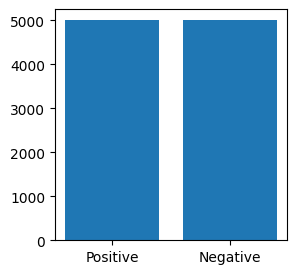

In [ ]:
#Declare a figure with a custom size
fig = plt.figure(figsize=(3, 3))

#labels for the two classes
labels = 'Positive', 'Negative'

#sizes for each section
sizes = [y_positive, y_negative]

#Declare pie chart,where the slices will be ordered and plotted counter-clockwise:
plt.bar(labels,sizes)

plt.show()

In [ ]:
# Our selected sample,Complex enouggh to exemplify each step
tweet1=all_tweets.iloc[1000]
tweet1["Tweets"]

'@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.'

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [ ]:
#remove old style retweet text "RT"
tweet2=re.sub(r'^RT[\s]+','',tweet1["Tweets"])

#remove hyperlinks
tweet2=re.sub(r'https?:\/\/.*[\r\n]*','',tweet2)

#remove hashtags
#only removing the hash # sign from the word
tweet2=re.sub(r'#','',tweet2)
tweet2=re.sub(r'@\w+','',tweet2)
tweet2=re.sub(r'[:)|(:)]','',tweet2)
print(tweet1["Tweets"])
print("\n Cleaned tweet\n", tweet2)




@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.

 Cleaned tweet
  Thanks for the favorite!  Make sure to keep in touch for more news of our light bulbs made from corn waste.


In [ ]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:\n')
print(tweet_tokens)


Tokenized string:

['thanks', 'for', 'the', 'favorite', '!', 'make', 'sure', 'to', 'keep', 'in', 'touch', 'for', 'more', 'news', 'of', 'our', 'light', 'bulbs', 'made', 'from', 'corn', 'waste', '.']


In [ ]:
#download the english stopwords
nltk.download('stopwords')
stopwords_english = stopwords.words('english')
print('stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stopwords_english = stopwords.words('english')
print('stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [ ]:
#print()
#print('\033[92m')
print(tweet_tokens)
print()
# print('\033[94m')
tweet_clean=[]
for word in tweet_tokens:
    if (word not in stopwords_english and word not in string.punctuation):
        tweet_clean.append(word)
print('removed stop word and punctuation')
print(tweet_clean)

['thanks', 'for', 'the', 'favorite', '!', 'make', 'sure', 'to', 'keep', 'in', 'touch', 'for', 'more', 'news', 'of', 'our', 'light', 'bulbs', 'made', 'from', 'corn', 'waste', '.']

removed stop word and punctuation
['thanks', 'favorite', 'make', 'sure', 'keep', 'touch', 'news', 'light', 'bulbs', 'made', 'corn', 'waste']


In [ ]:
def process_tweet(tweet):
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+','',tweet)

    # remove hyperlinks
    tweet = re.sub(r'https?://.*[\r\n]*','',tweet)

    # remove hashtags and mentions
    tweet = re.sub(r'#','',tweet)
    tweet = re.sub(r'@\w+','',tweet)

    # remove colons and parentheses (if intended as part of cleaning, otherwise remove this line)
    tweet = re.sub(r'[:)|(:)]','',tweet)

    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean=[]
    for word in tweet_tokens:
        if (word not in stopwords_english and word not in string.punctuation):
            tweets_clean.append(word)
    return tweets_clean

In [ ]:
processed_tweets=all_tweets['Tweets'].apply(process_tweet)
all_tweets['Tweets_processed']=processed_tweets
pd.set_option('display.max_colwidth', None)
all_tweets

,Tweets,Sentiment,Sentiments,Tweets_processed
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",NaN,Negative,"[love, feel, emm, think]"
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),Positive,NaN,"[thanks, guys]"
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",Positive,NaN,"[love, lord, better, life, <3]"
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,Positive,NaN,"[yeah, better, use, official, account, like, ❤, ️]"
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,Positive,NaN,"[ok, good, night, wish, troye, ugly, met, today, ok, today, fun, excited, tmrw]"
...,...,...,...,...
9995,My nose and forehead are peeling :(,NaN,Negative,"[nose, forehead, peeling]"
9996,@LittleMix come to Belgium :(,NaN,Negative,"[come, belgium]"
9997,WHY MUST THE VIDEO STOP THO :(,NaN,Negative,"[must, video, stop, tho]"
9998,@jeremygutsche we like this amazing donut recipe! we share with #foiegras lovers! :),Positive,NaN,"[like, amazing, donut, recipe, share, foiegras, lovers]"
